# Rate-modulated savings — isolated test on the validated substrate

Per Jasper's message (relayed via Claude web chat, 2026-07-18). Savings was confirmed absent
on the plain two-layer mechanism (phase-4 return slope 0.0206 < phase-1 cold-start slope
0.0360) — `w_char` only ever affected retrieval bias, never acquisition rate. This build adds
rate modulation:

```
increment_fast_effective = increment_fast * (1 + k * (w_char - 1))
w_fast = w_fast + decay_fast * (1 - w_fast) + increment_fast_effective * retrieval_weights
```

`k=0.5`, first pass, not tuned. Explicitly **not** in scope this round: episodic layer,
variable-size X, pruning, salience.

**Named risk to check directly, not assume away:** high `w_char` → faster `w_fast` growth →
faster `w_char` growth (via the existing consolidation term) → even faster `w_fast` growth.
This is a second feedback loop stacked on top of the one that already blew up once (the
original unbounded-`w_char` bug from `two_layer_consolidation.ipynb`). The existing
`w_char_max` ceiling bounds `w_char`'s value but says nothing about how fast `w_fast` can run
away *before* `w_char` saturates — that has to be checked, not assumed.

**Three possible outcomes, stated before running anything:**
- **A — real savings, no lock-in:** graded ordering survives, content-match rates stay
  comparable to the `k=0` baseline, phase-4 slope genuinely exceeds phase-1 cold-start slope
  (not just the phase-5 cross-pattern control), and `w_fast`'s phase-4 climb doesn't show an
  anomalous front-loaded/accelerating shape.
- **B — lock-in reopened:** ordering breaks (monopolization), content-match rates during
  phases 2-3 degrade vs. the `k=0` baseline, and/or phase-4 `w_fast` shows a convex/accelerating
  early shape — evidence the second feedback loop is firing, even if final numbers "look better."
- **C — no effect:** ordering and content-match both fine, but phase-4 slope still doesn't
  exceed phase-1 slope — savings still absent even with rate modulation.

Both `k=0` (baseline control, same seed/schedule) and `k=0.5` (test) are run in this notebook
so the comparison is apples-to-apples and doesn't rely on remembering numbers from a different
notebook run.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
torch.manual_seed(42)
n_patterns = 5
dim = 64

X = torch.randn(n_patterns, dim, device=device)
X = F.normalize(X, dim=1)

In [3]:
decay_fast = 0.02
increment_fast = 0.1
decay_char = 0.0005
consolidation_rate = 0.01
char_weight = 1.0
w_char_max = 10.0

def make_update_fn(k):
    def update_two_layer(w_fast, w_char, retrieval_weights):
        increment_fast_effective = increment_fast * (1 + k * (w_char - 1))
        w_fast = w_fast + decay_fast * (1 - w_fast) + increment_fast_effective * retrieval_weights
        headroom = (w_char_max - w_char).clamp(min=0) / w_char_max
        w_char = w_char + decay_char * (1 - w_char) + consolidation_rate * (w_fast - 1).clamp(min=0) * headroom
        return w_fast, w_char
    return update_two_layer

def retrieve_two_layer(query, X, w_fast, w_char, beta=4.0):
    similarities = X @ query
    biased = beta * similarities + torch.log(w_fast) + char_weight * torch.log(w_char)
    weights = F.softmax(biased, dim=0)
    retrieved = X.T @ weights
    return retrieved, weights

def run_two_layer_experiment(k, phase_len, phase_patterns, seed=0, dominant_prob=0.7):
    update_two_layer = make_update_fn(k)
    n_phases = len(phase_patterns)
    n_steps = phase_len * n_phases

    w_fast = torch.ones(n_patterns, device=device)
    w_char = torch.ones(n_patterns, device=device)
    fast_history = torch.zeros(n_steps, n_patterns)
    char_history = torch.zeros(n_steps, n_patterns)
    queried_idx_history = torch.zeros(n_steps, dtype=torch.long)
    won_idx_history = torch.zeros(n_steps, dtype=torch.long)

    minor_prob = (1 - dominant_prob) / (n_patterns - 1)

    torch.manual_seed(seed)
    for step in range(n_steps):
        phase = step // phase_len
        dom = phase_patterns[phase]
        probs = torch.full((n_patterns,), minor_prob)
        probs[dom] = dominant_prob

        idx = torch.multinomial(probs, 1).item()
        query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)

        retrieved, retrieval_weights = retrieve_two_layer(query, X, w_fast, w_char, beta=4.0)
        w_fast, w_char = update_two_layer(w_fast, w_char, retrieval_weights)

        fast_history[step] = w_fast
        char_history[step] = w_char
        queried_idx_history[step] = idx
        won_idx_history[step] = retrieval_weights.argmax()

    phase_bounds = [i * phase_len for i in range(n_phases + 1)]
    return {"fast": fast_history, "char": char_history, "queried": queried_idx_history,
            "won": won_idx_history, "phase_bounds": phase_bounds}

## Run both k=0 (control) and k=0.5 (test), same 5-phase schedule as the validated diagnostics run

In [4]:
phase_patterns = [0, 1, 2, 0, 3]
run_k0 = run_two_layer_experiment(k=0.0, phase_len=400, phase_patterns=phase_patterns, seed=0)
run_k05 = run_two_layer_experiment(k=0.5, phase_len=400, phase_patterns=phase_patterns, seed=0)
pb = run_k0["phase_bounds"]

print("k=0 final w_fast:", run_k0["fast"][-1])
print("k=0 final w_char:", run_k0["char"][-1])
print("k=0.5 final w_fast:", run_k05["fast"][-1])
print("k=0.5 final w_char:", run_k05["char"][-1])

k=0 final w_fast: tensor([1.7128, 1.7331, 1.5558, 3.7147, 1.2837])
k=0 final w_char: tensor([7.9532, 6.2345, 6.1958, 6.2645, 3.8202])
k=0.5 final w_fast: tensor([23.3037,  1.1987,  1.1817,  2.1405,  1.0993])
k=0.5 final w_char: tensor([9.8067, 2.3835, 2.6028, 3.1235, 1.9904])


## Check 1 — does the graded, non-monopolizing ordering survive?

Same metric as the parameter sweep: final `w_char` order and top/second-place ratio
(monopolization flagged above 5x, same threshold used throughout this experiment series).

In [5]:
def ordering_check(char_history, label):
    final_char = char_history[-1]
    sorted_vals, sorted_idx = torch.sort(final_char, descending=True)
    ratio = (sorted_vals[0] / sorted_vals[1]).item()
    print(f"{label}: final w_char = {[round(v, 2) for v in final_char.tolist()]}")
    print(f"  order (high->low) = {sorted_idx.tolist()}, top/second ratio = {ratio:.2f}, "
          f"monopolized = {ratio > 5.0}")

ordering_check(run_k0["char"], "k=0 (control)")
ordering_check(run_k05["char"], "k=0.5 (test)")

k=0 (control): final w_char = [7.95, 6.23, 6.2, 6.26, 3.82]
  order (high->low) = [0, 3, 1, 2, 4], top/second ratio = 1.27, monopolized = False
k=0.5 (test): final w_char = [9.81, 2.38, 2.6, 3.12, 1.99]
  order (high->low) = [0, 3, 2, 1, 4], top/second ratio = 3.14, monopolized = False


## Check 2 — content-match rate per phase (direct lock-in check, not just final ordering)

This is the check the message specifically asked for: don't assume the `w_char_max` ceiling
protects retrieval fidelity just because final numbers look graded — verify the actual
per-phase content-match rate isn't degrading vs. the `k=0` control.

In [6]:
def content_match_report(run, phase_patterns, phase_len, label):
    pb = run["phase_bounds"]
    print(label + ":")
    for p, dom in enumerate(phase_patterns):
        lo, hi = pb[p], pb[p + 1]
        q = run["queried"][lo:hi]
        w = run["won"][lo:hi]
        match_rate = (q == w).float().mean().item()
        print(f"  phase {p+1} (dominant=pattern {dom}): content-match rate = {match_rate*100:.1f}%")

content_match_report(run_k0, phase_patterns, 400, "k=0 (control)")
content_match_report(run_k05, phase_patterns, 400, "k=0.5 (test)")

k=0 (control):
  phase 1 (dominant=pattern 0): content-match rate = 81.2%
  phase 2 (dominant=pattern 1): content-match rate = 44.7%
  phase 3 (dominant=pattern 2): content-match rate = 78.0%
  phase 4 (dominant=pattern 0): content-match rate = 81.7%
  phase 5 (dominant=pattern 3): content-match rate = 86.0%
k=0.5 (test):
  phase 1 (dominant=pattern 0): content-match rate = 78.8%
  phase 2 (dominant=pattern 1): content-match rate = 7.8%
  phase 3 (dominant=pattern 2): content-match rate = 6.2%
  phase 4 (dominant=pattern 0): content-match rate = 67.0%
  phase 5 (dominant=pattern 3): content-match rate = 9.3%


## Check 3 — savings via slope comparison (same methodology as before)

Phase 1 (pattern 0, true cold start) vs phase 4 (pattern 0, return) vs phase 5 (pattern 3,
cross-pattern cold start). The real question: does phase 4's slope now exceed phase 1's own
cold-start slope, not just the cross-pattern control?

In [7]:
def climb_stats(fast_history, pattern_idx, phase_start, phase_end, label, verbose=True):
    segment = fast_history[phase_start:phase_end, pattern_idx].numpy()
    start_val = segment[0]
    peak_val = segment.max()
    net_increase = peak_val - start_val

    kernel = np.ones(10) / 10
    smoothed = np.convolve(segment, kernel, mode="valid")
    threshold = start_val + 0.9 * net_increase
    hits = np.nonzero(smoothed >= threshold)[0]
    steps_to_90pct = int(hits[0]) if len(hits) > 0 else None

    x = np.arange(50)
    slope, intercept = np.polyfit(x, segment[:50], 1)

    if verbose:
        print(f"{label}: start={start_val:.3f} peak={peak_val:.3f} net_increase={net_increase:.3f} "
              f"steps_to_90%={steps_to_90pct} initial_slope(50 steps)={slope:.4f}")
    return {"start": start_val, "peak": peak_val, "net_increase": net_increase,
            "steps_to_90pct": steps_to_90pct, "slope": slope, "segment": segment}

print("--- k=0 (control, should reproduce prior diagnostics numbers: ~209/175/308 steps, ~0.036/0.021/0.012 slope) ---")
r_k0_p1 = climb_stats(run_k0["fast"], 0, pb[0], pb[1], "phase 1, pattern 0 (cold start)")
r_k0_p4 = climb_stats(run_k0["fast"], 0, pb[3], pb[4], "phase 4, pattern 0 (return)")
r_k0_p5 = climb_stats(run_k0["fast"], 3, pb[4], pb[5], "phase 5, pattern 3 (cross-pattern control)")

print()
print("--- k=0.5 (test) ---")
r_k05_p1 = climb_stats(run_k05["fast"], 0, pb[0], pb[1], "phase 1, pattern 0 (cold start)")
r_k05_p4 = climb_stats(run_k05["fast"], 0, pb[3], pb[4], "phase 4, pattern 0 (return)")
r_k05_p5 = climb_stats(run_k05["fast"], 3, pb[4], pb[5], "phase 5, pattern 3 (cross-pattern control)")

--- k=0 (control, should reproduce prior diagnostics numbers: ~209/175/308 steps, ~0.036/0.021/0.012 slope) ---
phase 1, pattern 0 (cold start): start=1.015 peak=5.271 net_increase=4.256 steps_to_90%=209 initial_slope(50 steps)=0.0360
phase 4, pattern 0 (return): start=2.012 peak=4.539 net_increase=2.527 steps_to_90%=175 initial_slope(50 steps)=0.0206
phase 5, pattern 3 (cross-pattern control): start=1.326 peak=3.750 net_increase=2.424 steps_to_90%=308 initial_slope(50 steps)=0.0118

--- k=0.5 (test) ---
phase 1, pattern 0 (cold start): start=1.015 peak=26.285 net_increase=25.270 steps_to_90%=319 initial_slope(50 steps)=0.0391
phase 4, pattern 0 (return): start=25.875 peak=27.324 net_increase=1.450 steps_to_90%=108 initial_slope(50 steps)=0.0147
phase 5, pattern 3 (cross-pattern control): start=1.082 peak=2.150 net_increase=1.068 steps_to_90%=381 initial_slope(50 steps)=0.0027


In [8]:
print("Savings verdict, k=0.5:")
print(f"  phase4 slope ({r_k05_p4['slope']:.4f}) > phase1 slope ({r_k05_p1['slope']:.4f})? "
      f"{r_k05_p4['slope'] > r_k05_p1['slope']}")
print(f"  phase4 slope ({r_k05_p4['slope']:.4f}) > phase5 slope ({r_k05_p5['slope']:.4f})? "
      f"{r_k05_p4['slope'] > r_k05_p5['slope']}")
print()
print("For comparison, k=0 control:")
print(f"  phase4 slope ({r_k0_p4['slope']:.4f}) > phase1 slope ({r_k0_p1['slope']:.4f})? "
      f"{r_k0_p4['slope'] > r_k0_p1['slope']}")

Savings verdict, k=0.5:
  phase4 slope (0.0147) > phase1 slope (0.0391)? False
  phase4 slope (0.0147) > phase5 slope (0.0027)? True

For comparison, k=0 control:
  phase4 slope (0.0206) > phase1 slope (0.0360)? False


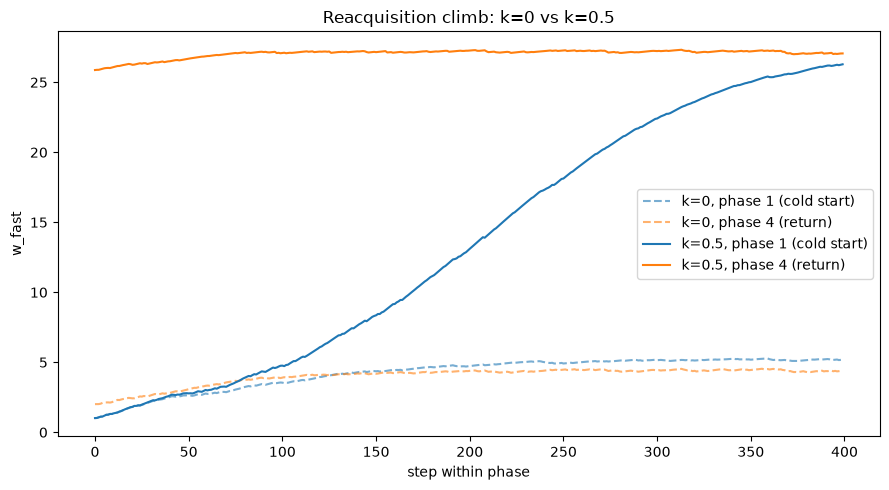

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(r_k0_p1["segment"], '--', color='tab:blue', alpha=0.6, label="k=0, phase 1 (cold start)")
plt.plot(r_k0_p4["segment"], '--', color='tab:orange', alpha=0.6, label="k=0, phase 4 (return)")
plt.plot(r_k05_p1["segment"], color='tab:blue', label="k=0.5, phase 1 (cold start)")
plt.plot(r_k05_p4["segment"], color='tab:orange', label="k=0.5, phase 4 (return)")
plt.xlabel("step within phase")
plt.ylabel("w_fast")
plt.title("Reacquisition climb: k=0 vs k=0.5")
plt.legend()
plt.tight_layout()
plt.savefig("savings_k_comparison.png", dpi=100)
plt.show()

## Check 4 — w_fast trajectory shape in phase 4: is it front-loading (evidence of the loop firing)?

The rate-modulation formula uses residual `w_char` as a direct multiplier on
`increment_fast`, so phase 4 starting with elevated `w_char[0]` will trivially get a bigger
increment than phase 1 (which starts at `w_char=1`, no boost) — that's built into the design,
not surprising on its own. The real question is whether growth *accelerates* over the early
window (rate increasing as `w_fast` and `w_char` reinforce each other) rather than the
expected decelerating-toward-saturation shape. Binning the early climb into 25-step segments
and comparing slopes within phase 4 directly tests this.

In [10]:
def binned_slopes(segment, bin_size=25, n_bins=6):
    slopes = []
    for b in range(n_bins):
        lo, hi = b * bin_size, (b + 1) * bin_size
        x = np.arange(hi - lo)
        y = segment[lo:hi]
        slope, _ = np.polyfit(x, y, 1)
        slopes.append(slope)
    return slopes

print("Binned slopes (25-step windows) during phase 4, pattern 0:")
print(f"  k=0:   {[round(s, 4) for s in binned_slopes(r_k0_p4['segment'])]}")
print(f"  k=0.5: {[round(s, 4) for s in binned_slopes(r_k05_p4['segment'])]}")
print()
print("For reference, entering-phase-4 w_char[0] values (the multiplier driving any front-loading):")
print(f"  k=0:   w_char[0] at start of phase 4 = {run_k0['char'][pb[3], 0].item():.3f}")
print(f"  k=0.5: w_char[0] at start of phase 4 = {run_k05['char'][pb[3], 0].item():.3f}")

k05_bins = binned_slopes(r_k05_p4['segment'])
accelerating = any(k05_bins[i+1] > k05_bins[i] * 1.2 for i in range(2))  # meaningfully increasing in the first 3 bins
print(f"\nk=0.5 slope increasing (not just decelerating toward saturation) in early bins: {accelerating}")

Binned slopes (25-step windows) during phase 4, pattern 0:
  k=0:   [np.float64(0.0234), np.float64(0.0195), np.float64(0.0227), np.float64(0.0095), np.float64(0.0094), np.float64(0.0045)]
  k=0.5: [np.float64(0.0206), np.float64(0.0136), np.float64(0.0156), np.float64(0.0015), np.float64(0.0048), np.float64(0.0015)]

For reference, entering-phase-4 w_char[0] values (the multiplier driving any front-loading):
  k=0:   w_char[0] at start of phase 4 = 7.755
  k=0.5: w_char[0] at start of phase 4 = 9.822

k=0.5 slope increasing (not just decelerating toward saturation) in early bins: False
